CNN model with 5 feature (Open, High, Low, Close, Volume)

In [47]:
# Standard library
import os
import random
from datetime import datetime, timedelta

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D, GlobalAveragePooling1D, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Removing randomness from the model to enforce consistent results

In [48]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

Loading roughly the last 10 years of APPL OHLCV data from CSV file (downloaded from Market Data API). 
Start Date: 2015-01-01, End Date: 2026-01-08

In [ ]:
#Loading the OHLCV data CSV file into a dataframe 
data = pd.read_csv("AAPL_15min_OHLCV.csv")

#Converts the timestamp column into a proper datetime object, which is easier for manipulation later on
data['timestamp'] = pd.to_datetime(data['timestamp'])

#Defining a list that only contains column names of the feature I will use to train my CNN model
features = ['close', 'open', 'high', 'low', 'volume']

#pandas typically use float64, but neural networks use float32 - so best practice do a datatype conversion 
#.values convert the array into a numpy array (multi-dimensional array) - which is common when using neural networks
feature_data = data[features].astype(np.float32).values

#Storing timestamps (which are useful for plotting/alignment later)
datetime_index = data['timestamp'].values

In [50]:
# Get the number of close prices
print(f"Number of close prices: {len(feature_data)}")

Number of close prices: 71793


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [51]:
total_size = len(feature_data)

#Defining the split size
#70% of the total data to be used for training, 15% for validation, and 15% for testing
train_size = int(len(feature_data) * 0.70)
val_size   = int(len(feature_data) * 0.15)

#Chronogically splitting the data so first 70% is training, the next 15% is validation and the remaining 15% is testing
train_data = feature_data[:train_size] #gets items from 0 to 69
val_data = feature_data[train_size:train_size + val_size] #gets items from 69 to 84
test_data = feature_data[train_size + val_size:] #gets items from 85 to 99

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_data)} samples ({len(train_data)/total_size:.2%})")
print(f"Validation set : {len(val_data)} samples ({len(val_data)/total_size:.2%})")
print(f"Test set       : {len(test_data)} samples ({len(test_data)/total_size:.2%})")

print("Train:", train_data.shape)
print("Val  :", val_data.shape)
print("Test :", test_data.shape)

print("\nCheck sum:", len(train_data) + len(val_data) + len(test_data))

Total samples: 71793

Dataset sizes:
Training set   : 50255 samples (70.00%)
Validation set : 10768 samples (15.00%)
Test set       : 10770 samples (15.00%)
Train: (50255, 5)
Val  : (10768, 5)
Test : (10770, 5)

Check sum: 71793


Normalizing my data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks. Need to Scale ALL features

In [52]:
#Calculating the number of features, and creating a seperate scaler for each feature
num_features = train_data.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
#Here we just calculate and store the min and max values for each feature
for i, scaler in enumerate(scalers):
    scaler.fit(train_data[:, [i]]) #gets all rows, and just spefific columns - for each feature

#Transform each column individually using its corresponding scaler
#Transforming means actually applying the MinMax formula to get new values between 0-1
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_scaled = scale_data(train_data, scalers)
val_scaled = scale_data(val_data, scalers)
test_scaled = scale_data(test_data, scalers)

print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("Val   scaled min/max:", val_scaled.min(), val_scaled.max())
print("Test  scaled min/max:", test_scaled.min(), test_scaled.max())

Train scaled min/max: 0.0 1.0000001
Val   scaled min/max: 0.010080755 0.81538886
Test  scaled min/max: 0.0031608166 0.75775695


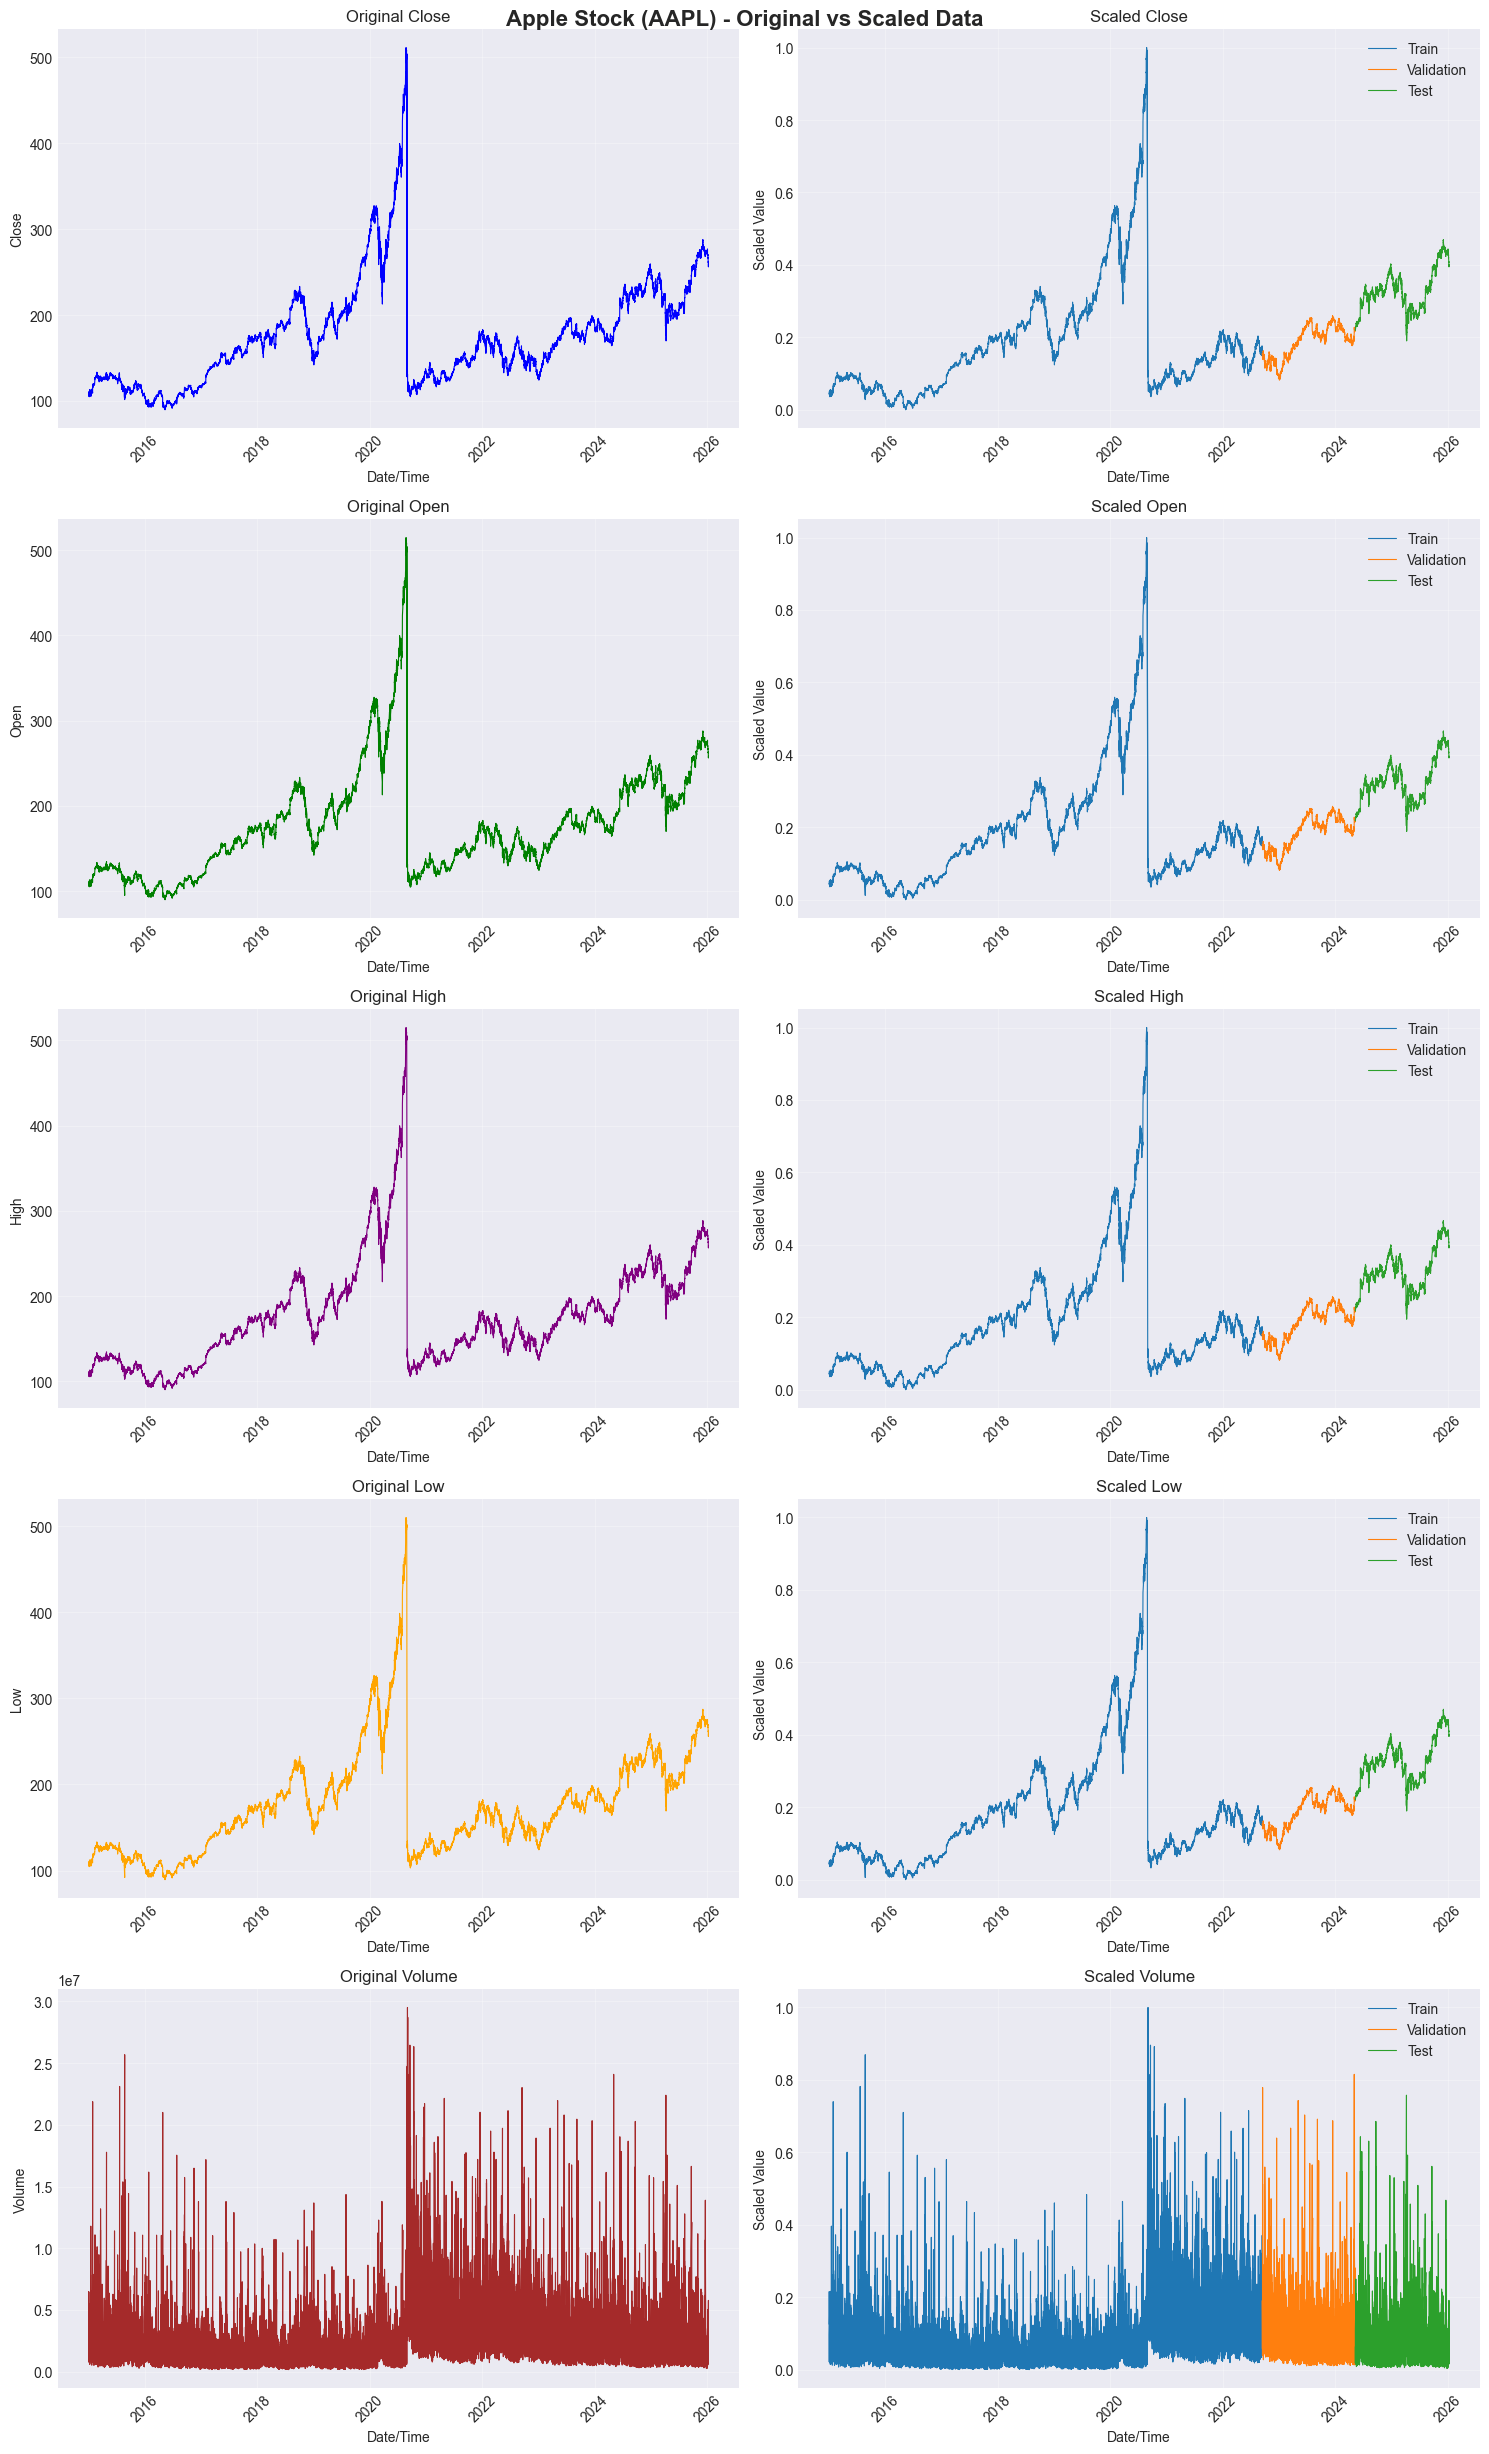

In [53]:
#Here we split the dateime index to match the training/valiation and test data splits.
#To ensure each data segment has corresponding timestamps for plotting
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_data.shape[1]

#Here we create the grid subplots as per the number of features we want to feed into our model 
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume']
colors = ['blue', 'green', 'purple', 'orange', 'brown']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, feature_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

Creating a Sliding Window for inputs to my CNN model - with continuity and context between sets

In [54]:
def create_multifeature_dataset_with_context(data, time_step = 30, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-95 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 96)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 30

X_train, y_train = create_multifeature_dataset_with_context(train_scaled, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_scaled, time_step, context_data=train_scaled)
X_test, y_test   = create_multifeature_dataset_with_context(test_scaled, time_step, context_data=val_scaled)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (50225, 30, 5), y_train: (50225,)
X_val  : (10768, 30, 5), y_val  : (10768,)
X_test : (10770, 30, 5), y_test : (10770,)


Building and training my CNN model

In [55]:
model = Sequential()

# Conv layer + Pooling
model.add(Input(shape=(X_train.shape[1], X_train.shape[2]))),
model.add(Conv1D(32, kernel_size=5, padding='same', activation='relu'))
model.add(Conv1D(32, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.25))

model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  

model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['mae'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6         
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=100,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 4.3774e-04 - mae: 0.0106 - val_loss: 1.7331e-04 - val_mae: 0.0112 - learning_rate: 1.0000e-04
Epoch 2/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 3.5771e-04 - mae: 0.0091 - val_loss: 1.7671e-04 - val_mae: 0.0114 - learning_rate: 1.0000e-04
Epoch 3/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 3.5207e-04 - mae: 0.0088 - val_loss: 1.7695e-04 - val_mae: 0.0113 - learning_rate: 1.0000e-04
Epoch 4/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 3.4587e-04 - mae: 0.0088 - val_loss: 1.0227e-04 - val_mae: 0.0084 - learning_rate: 1.0000e-04
Epoch 5/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 3.3383e-04 - mae: 0.0086 - val_loss: 7.6574e-05 - val_mae: 0.0072 - learning_rate: 1.0000e-04
Epoch 6/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 3.1903e-04 - mae: 0.0083 - val_loss: 7.0781e-05 - val_mae: 0.0069 - learning_rate: 1.0000e-04
Epoch 7/100
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 13s 8m

A graph to visualize the training process - to check if the model is overfitting

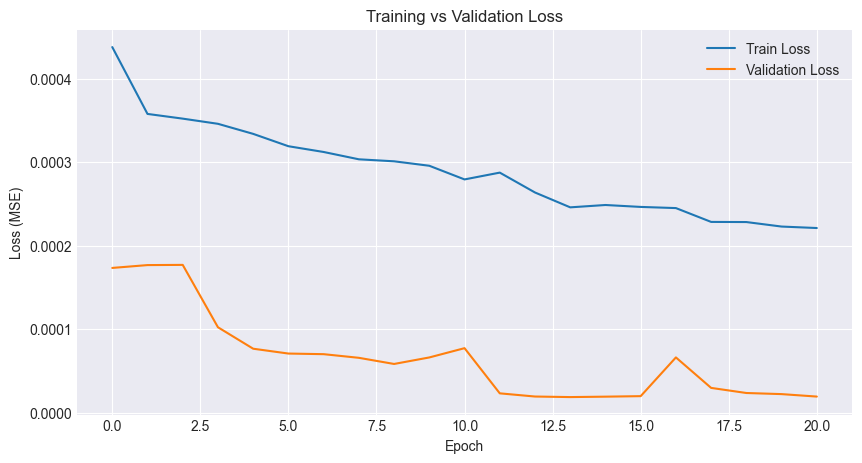

In [56]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Making predictions from the trained model

In [57]:
#This gets the predictions from the trained model - but these are scaled from (0-1 range) beacuse the model was trained on scaled data
predictions_scaled = model.predict(X_test)

# inverse_transform reverses the scaling applied earlier and converts predictions from 0-1 range back to actual dollar values
#here we reverse the scaling of our models predicted values
predictions = scalers[0].inverse_transform(predictions_scaled)

#here we reverse the scaling of our models actual values
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

# Flatten the 2D array back to 1D arrays which is easier for metrics calculations
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

# Calculate metrics on unscaled data
#RMSE (Root Mean Squared Error): Average prediction error, penalizes large errors more
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))

#MAE (Mean Absolute Error): Average absolute difference between predicted and actual prices
mae = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE): ${mae:.2f}")


337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Unscaled Root Mean Squared Error (RMSE): $3.36
Unscaled Mean Absolute Error (MAE): $2.20


A graph to visualize the predictions made from the model vs actual prices

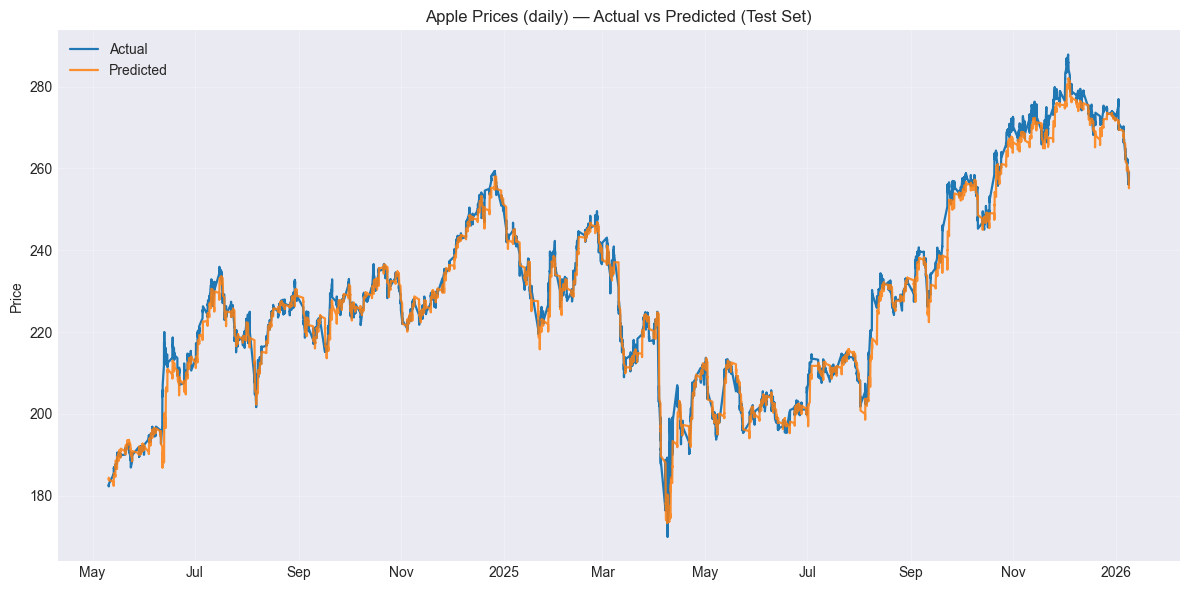

In [58]:
#Here we calculate the number of samples in each data split, so it tells the model the test data begins after the validation set
total_samples_train = len(X_train)
total_samples_val = len(X_val)
total_samples_test = len(X_test)

train_end = int(len(feature_data) * 0.70) 
val_end = int(len(feature_data) * 0.85)

#here we calculate where the predictions actually start
#The test data prediction starts where the validation set ends + the window size 
y_test_start_idx = val_end + time_step
y_test_end_idx = y_test_start_idx + len(y_test)

#here we get the align the dates with predictions 
dates_test = datetime_index[-len(predictions):]

# 4) Plot with real dates on the x-axis
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled.flatten(), label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions.flatten(), label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.legend()

# Nice datetime formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show() 

Checking the Accuracy of my model: